In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [157]:
df = pd.read_csv("Data\loan.csv")

In [158]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
df_cl = df.copy()
df_cl.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose',
       'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    

| Column                        | Meaning                                                                        |
| ----------------------------- | ------------------------------------------------------------------------------ |
| `id`                          | Unique identifier assigned to each loan.                                       |
| `member_id`                   | Unique identifier assigned to the borrower (member).                           |
| `loan_amnt`                   | Amount of money requested by the borrower.                                     |
| `funded_amnt`                 | Amount actually funded by investors.                                           |
| `funded_amnt_inv`             | Amount funded specifically by individual investors.                            |
| `term`                        | Length of the loan repayment period (e.g., 36 or 60 months).                   |
| `int_rate`                    | Annual interest rate charged on the loan.                                      |
| `installment`                 | Fixed monthly payment required to repay the loan.                              |
| `grade`                       | LendingClub's overall credit grade assigned to the loan (A–G).                 |
| `sub_grade`                   | More detailed credit grade within each grade (e.g., A1–G5).                    |
| `emp_title`                   | Borrower's job title.                                                          |
| `emp_length`                  | Number of years the borrower has been employed.                                |
| `home_ownership`              | Borrower's home ownership status (Rent, Mortgage, Own, etc.).                  |
| `annual_inc`                  | Borrower's reported annual income.                                             |
| `verification_status`         | Indicates whether the borrower's income was verified.                          |
| `issue_d`                     | Month when the loan was issued.                                                |
| `loan_status`                 | Final or current status of the loan (Fully Paid, Charged Off, etc.).           |
| `pymnt_plan`                  | Indicates whether the borrower is on a payment plan.                           |
| `url`                         | Webpage URL for the LendingClub loan listing.                                  |
| `desc`                        | Borrower's optional description of the loan purpose.                           |
| `purpose`                     | General purpose for requesting the loan (debt consolidation, car, etc.).       |
| `title`                       | Short title provided by the borrower for the loan.                             |
| `zip_code`                    | First three digits of the borrower's ZIP code.                                 |
| `addr_state`                  | State where the borrower resides.                                              |
| `dti`                         | Debt-to-income ratio of the borrower.                                          |
| `delinq_2yrs`                 | Number of delinquencies in the past two years.                                 |
| `earliest_cr_line`            | Date when the borrower's oldest credit account was opened.                     |
| `inq_last_6mths`              | Number of credit inquiries made in the last six months.                        |
| `mths_since_last_delinq`      | Months since the borrower's last delinquency.                                  |
| `mths_since_last_record`      | Months since the borrower's last public record.                                |
| `open_acc`                    | Number of currently open credit accounts.                                      |
| `pub_rec`                     | Number of derogatory public records.                                           |
| `revol_bal`                   | Total outstanding balance on revolving credit accounts.                        |
| `revol_util`                  | Percentage of revolving credit currently being used.                           |
| `total_acc`                   | Total number of credit accounts the borrower has ever had.                     |
| `initial_list_status`         | Initial listing status of the loan (`f` = whole loan, `w` = fractional).       |
| `out_prncp`                   | Remaining unpaid principal balance.                                            |
| `out_prncp_inv`               | Remaining unpaid principal owed to investors.                                  |
| `total_pymnt`                 | Total amount paid by the borrower.                                             |
| `total_pymnt_inv`             | Total amount paid to investors.                                                |
| `total_rec_prncp`             | Total principal repaid by the borrower.                                        |
| `total_rec_int`               | Total interest collected on the loan.                                          |
| `total_rec_late_fee`          | Total late fees collected.                                                     |
| `recoveries`                  | Amount recovered after the loan was charged off.                               |
| `collection_recovery_fee`     | Fees paid for collecting recovered funds.                                      |
| `last_pymnt_d`                | Date of the borrower's last payment.                                           |
| `last_pymnt_amnt`             | Amount of the borrower's last payment.                                         |
| `next_pymnt_d`                | Scheduled date of the next payment.                                            |
| `last_credit_pull_d`          | Date when LendingClub last obtained the borrower's credit report.              |
| `collections_12_mths_ex_med`  | Number of collections in the past 12 months, excluding medical collections.    |
| `mths_since_last_major_derog` | Months since the borrower's last major derogatory credit event.                |
| `policy_code`                 | Internal LendingClub policy code.                                              |
| `application_type`            | Indicates whether the loan application is individual or joint.                 |
| `annual_inc_joint`            | Combined annual income for joint applicants.                                   |
| `dti_joint`                   | Combined debt-to-income ratio for joint applicants.                            |
| `verification_status_joint`   | Income verification status for joint applicants.                               |
| `acc_now_delinq`              | Number of accounts currently delinquent.                                       |
| `tot_coll_amt`                | Total amount ever sent to collections.                                         |
| `tot_cur_bal`                 | Total current balance across all accounts.                                     |
| `open_acc_6m`                 | Number of credit accounts opened during the last six months.                   |
| `open_il_6m`                  | Number of installment loan accounts opened during the last six months.         |
| `open_il_12m`                 | Number of installment loan accounts opened during the last twelve months.      |
| `open_il_24m`                 | Number of installment loan accounts opened during the last twenty-four months. |
| `mths_since_rcnt_il`          | Months since the most recent installment loan was opened.                      |
| `total_bal_il`                | Total outstanding balance on installment loans.                                |
| `il_util`                     | Utilization percentage of installment loan credit.                             |
| `open_rv_12m`                 | Number of revolving accounts opened during the last twelve months.             |
| `open_rv_24m`                 | Number of revolving accounts opened during the last twenty-four months.        |
| `max_bal_bc`                  | Highest balance among all bankcard accounts.                                   |
| `all_util`                    | Overall credit utilization across all accounts.                                |
| `total_rev_hi_lim`            | Total revolving credit limit.                                                  |
| `inq_fi`                      | Number of finance-related credit inquiries.                                    |
| `total_cu_tl`                 | Total number of credit union accounts.                                         |
| `inq_last_12m`                | Number of credit inquiries made during the last twelve months.                 |


# Terminologies

## Delinquency

A **delinquency** occurs when a borrower **fails to make a scheduled loan payment by its due date**. In credit risk analysis, delinquency is an early indicator of financial distress and is commonly measured by the number of days a payment is overdue (e.g., 30, 60, or 90 days past due). Borrowers with a history of delinquencies are generally considered to have a higher probability of default.

**Examples:**
- `delinq_2yrs`: Number of delinquent payment incidents during the past two years.
- `mths_since_last_delinq`: Number of months since the borrower's most recent delinquency.
- `acc_now_delinq`: Number of credit accounts that are currently delinquent.

In [160]:
print(df_cl['loan_status'].unique())

['Fully Paid' 'Charged Off' 'Current' 'Default' 'Late (31-120 days)'
 'In Grace Period' 'Late (16-30 days)'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off' 'Issued']


## Loan Status (`loan_status`)

The **`loan_status`** column describes the **current or final outcome of a loan**. It is the target variable in many credit risk prediction problems because it indicates whether a borrower successfully repaid the loan, is still making payments, or has defaulted.

| Loan Status | Meaning |
|-------------|---------|
| **Fully Paid** | The borrower repaid the entire loan, including all principal and interest, with no outstanding balance. |
| **Charged Off** | The lender considers the loan unlikely to be collected and records it as a loss. The borrower may still legally owe the debt, but it is treated as a default for accounting purposes. |
| **Current** | The borrower is making payments on time, and the loan is active with no overdue payments. |
| **Default** | The borrower has failed to meet the repayment obligations, and the loan is officially in default according to the lender's policy. |
| **Late (31–120 days)** | The borrower is between 31 and 120 days behind on scheduled payments. This represents a significant delinquency and increased credit risk. |
| **Late (16–30 days)** | The borrower is between 16 and 30 days behind on payments. This is an early stage of delinquency. |
| **In Grace Period** | The payment due date has passed, but the borrower is still within the lender's grace period and has not yet been reported as delinquent. |
| **Issued** | The loan has been approved and funded recently. Repayment has either not started or there is not enough payment history to determine its performance. |
| **Does not meet the credit policy. Status: Fully Paid** | The loan failed to satisfy the lender's standard credit policy but was still issued and ultimately repaid in full. |
| **Does not meet the credit policy. Status: Charged Off** | The loan failed to satisfy the lender's standard credit policy, was nevertheless issued, and ultimately resulted in a charge-off. |

### Typical Interpretation for Credit Risk

From **lowest** to **highest** credit risk:

1. **Fully Paid**
2. **Current**
3. **Issued**
4. **In Grace Period**
5. **Late (16–30 days)**
6. **Late (31–120 days)**
7. **Default**
8. **Charged Off**

In most credit risk classification tasks, the target variable is simplified into two classes:

- **Good Loans:** `Fully Paid`, `Current` 
- **Bad Loans:** `Charged Off`, `Default`

Depending on the objective, loans that are **Late** or **In Grace Period** may either be excluded from the analysis or treated as an intermediate risk category.

In [161]:
loan_types = {
    'good_loans' : [
    'Fully Paid', 'Current', 
    'Does not meet the credit policy. Status:Fully Paid'
    ],
    'bad_loans' : [
    'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Charged Off'
    ],
    'paid_loans' : [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'
    ],
    'unpaid_loans' : [
    'Charged Off',
    'Does not meet the credit policy. Status:Charged Off',
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)'
    ],
    'current_loans' : [
        'Issued',
        'In Grace Period',
        'Current',   
    ],
    'active_loans' : [
    'Current',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)',
    'Issued'
    ]
}

loan_type_indices = {
    'good_indices' : df_cl.index[df['loan_status'].isin(loan_types['good_loans'])],
    'bad_indices' : df_cl.index[df['loan_status'].isin(loan_types['bad_loans'])],
    'paid_indices' : df_cl.index[df['loan_status'].isin(loan_types['paid_loans'])],
    'unpaid_indices' : df_cl.index[df['loan_status'].isin(loan_types['unpaid_loans'])],
    'current_indices' : df_cl.index[df['loan_status'].isin(loan_types['current_loans'])],
    'active_indices' : df_cl.index[df['loan_status'].isin(loan_types['active_loans'])],
}

## Unpaid Loans Analysis

- We clean the `unpaid_loans` dataset by removing columns that contain more than **50% missing values**. The purpose of this step is to obtain a cleaner dataset for a general exploratory analysis while avoiding features with substantial missing information.

- We perform **Exploratory Data Analysis (EDA)** on the cleaned `unpaid_loans` dataset to better understand the characteristics of delinquent and defaulted loans. This analysis aims to identify common borrower traits, loan characteristics, and financial factors associated with unsuccessful loan repayment.

In [162]:
df_unpaid_loans = df_cl.iloc[loan_type_indices['unpaid_indices']].copy()
total_rows = df_unpaid_loans.shape[0]
col_unpaid_nan = [
    col 
    for col in df_unpaid_loans.columns
    if df_unpaid_loans[col].isna().sum()/total_rows > 0.5
]
len(col_unpaid_nan)
df_unpaid_loans.drop(columns=col_unpaid_nan, inplace=True)

In [163]:
df_unpaid_loans.isna().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_title                      4520
emp_length                     3472
home_ownership                    0
annual_inc                        0
verification_status               0
issue_d                           0
loan_status                       0
pymnt_plan                        0
url                               0
purpose                           0
title                             3
zip_code                          0
addr_state                        0
dti                               0
delinq_2yrs                       3
earliest_cr_line                  3
inq_last_6mths                    3
open_acc                    

In [164]:
# Fill missing text/categorical values with "Not Known"
# These columns describe the loan title, borrower's job title, and employment length.
# Since they are descriptive fields, replacing missing values with "Not Known" is reasonable.
df_unpaid_loans[['title', 'emp_title', 'emp_length']] = (
    df_unpaid_loans[['title', 'emp_title', 'emp_length']]
    .fillna('Not Known')
)

# Fill missing values in collections_12_mths_ex_med with 0
# This column represents the number of collections in the last 12 months,
# excluding medical collections. A missing value is treated as no collection record.
df_unpaid_loans['collections_12_mths_ex_med'] = (
    df_unpaid_loans['collections_12_mths_ex_med']
    .fillna(0)
)

# Fill missing balance/collection-related numeric columns with 0
# tot_coll_amt: total collection amount
# tot_cur_bal: total current balance
# total_rev_hi_lim: total revolving high credit limit
# Missing values are replaced with 0 to indicate no recorded amount.
df_unpaid_loans[['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']] = (
    df_unpaid_loans[['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']]
    .fillna(0)
)

# df_unpaid_laons[df_unpaid_laons['last_pyment_d'].isna()]
# All the tot_coll_amt of Nan values of last_pyment_d was 0.
# Fill missing last payment dates with the issue date
# For rows where last_pymnt_d is missing, we use issue_d as a substitute.
# This assumes that if no payment date is recorded, the loan issue date is the best available reference date.
mask = df_unpaid_loans['last_pymnt_d'].isna()
df_unpaid_loans.loc[mask, 'last_pymnt_d'] = df_unpaid_loans.loc[mask, 'issue_d']

# plt.hist(df_unpaid_loans['revol_util'], bins=20) # bell shaped
# Fill missing revolving utilization values with the mean
# A histogram showed that revol_util is approximately bell-shaped,
# so using the mean is a reasonable imputation method.
df_unpaid_loans['revol_util'] = df_unpaid_loans['revol_util'].fillna(
    df_unpaid_loans['revol_util'].mean()
)

df_cl.update(df_unpaid_loans)

# print(df_unpaid_loans.isna().sum().sum()) # Output: 28

# Drop any remaining rows with missing values
# After handling the important missing values above, this removes any leftover NaNs.
df_unpaid_loans.dropna(inplace=True)

In [165]:
df_unpaid_loans.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,Apr-2013,119.66,Sep-2013,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0
8,1071795,1306957,5600.0,5600.0,5600.0,60 months,21.28,152.39,F,F2,...,Apr-2012,152.39,Aug-2012,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0
9,1071570,1306721,5375.0,5375.0,5350.0,60 months,12.69,121.45,B,B5,...,Nov-2012,121.45,Mar-2013,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0
12,1064687,1298717,9000.0,9000.0,9000.0,36 months,13.49,305.38,C,C1,...,Jul-2012,305.38,Nov-2012,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0
14,1069057,1303503,10000.0,10000.0,10000.0,36 months,10.65,325.74,B,B2,...,Oct-2013,325.74,Mar-2014,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0


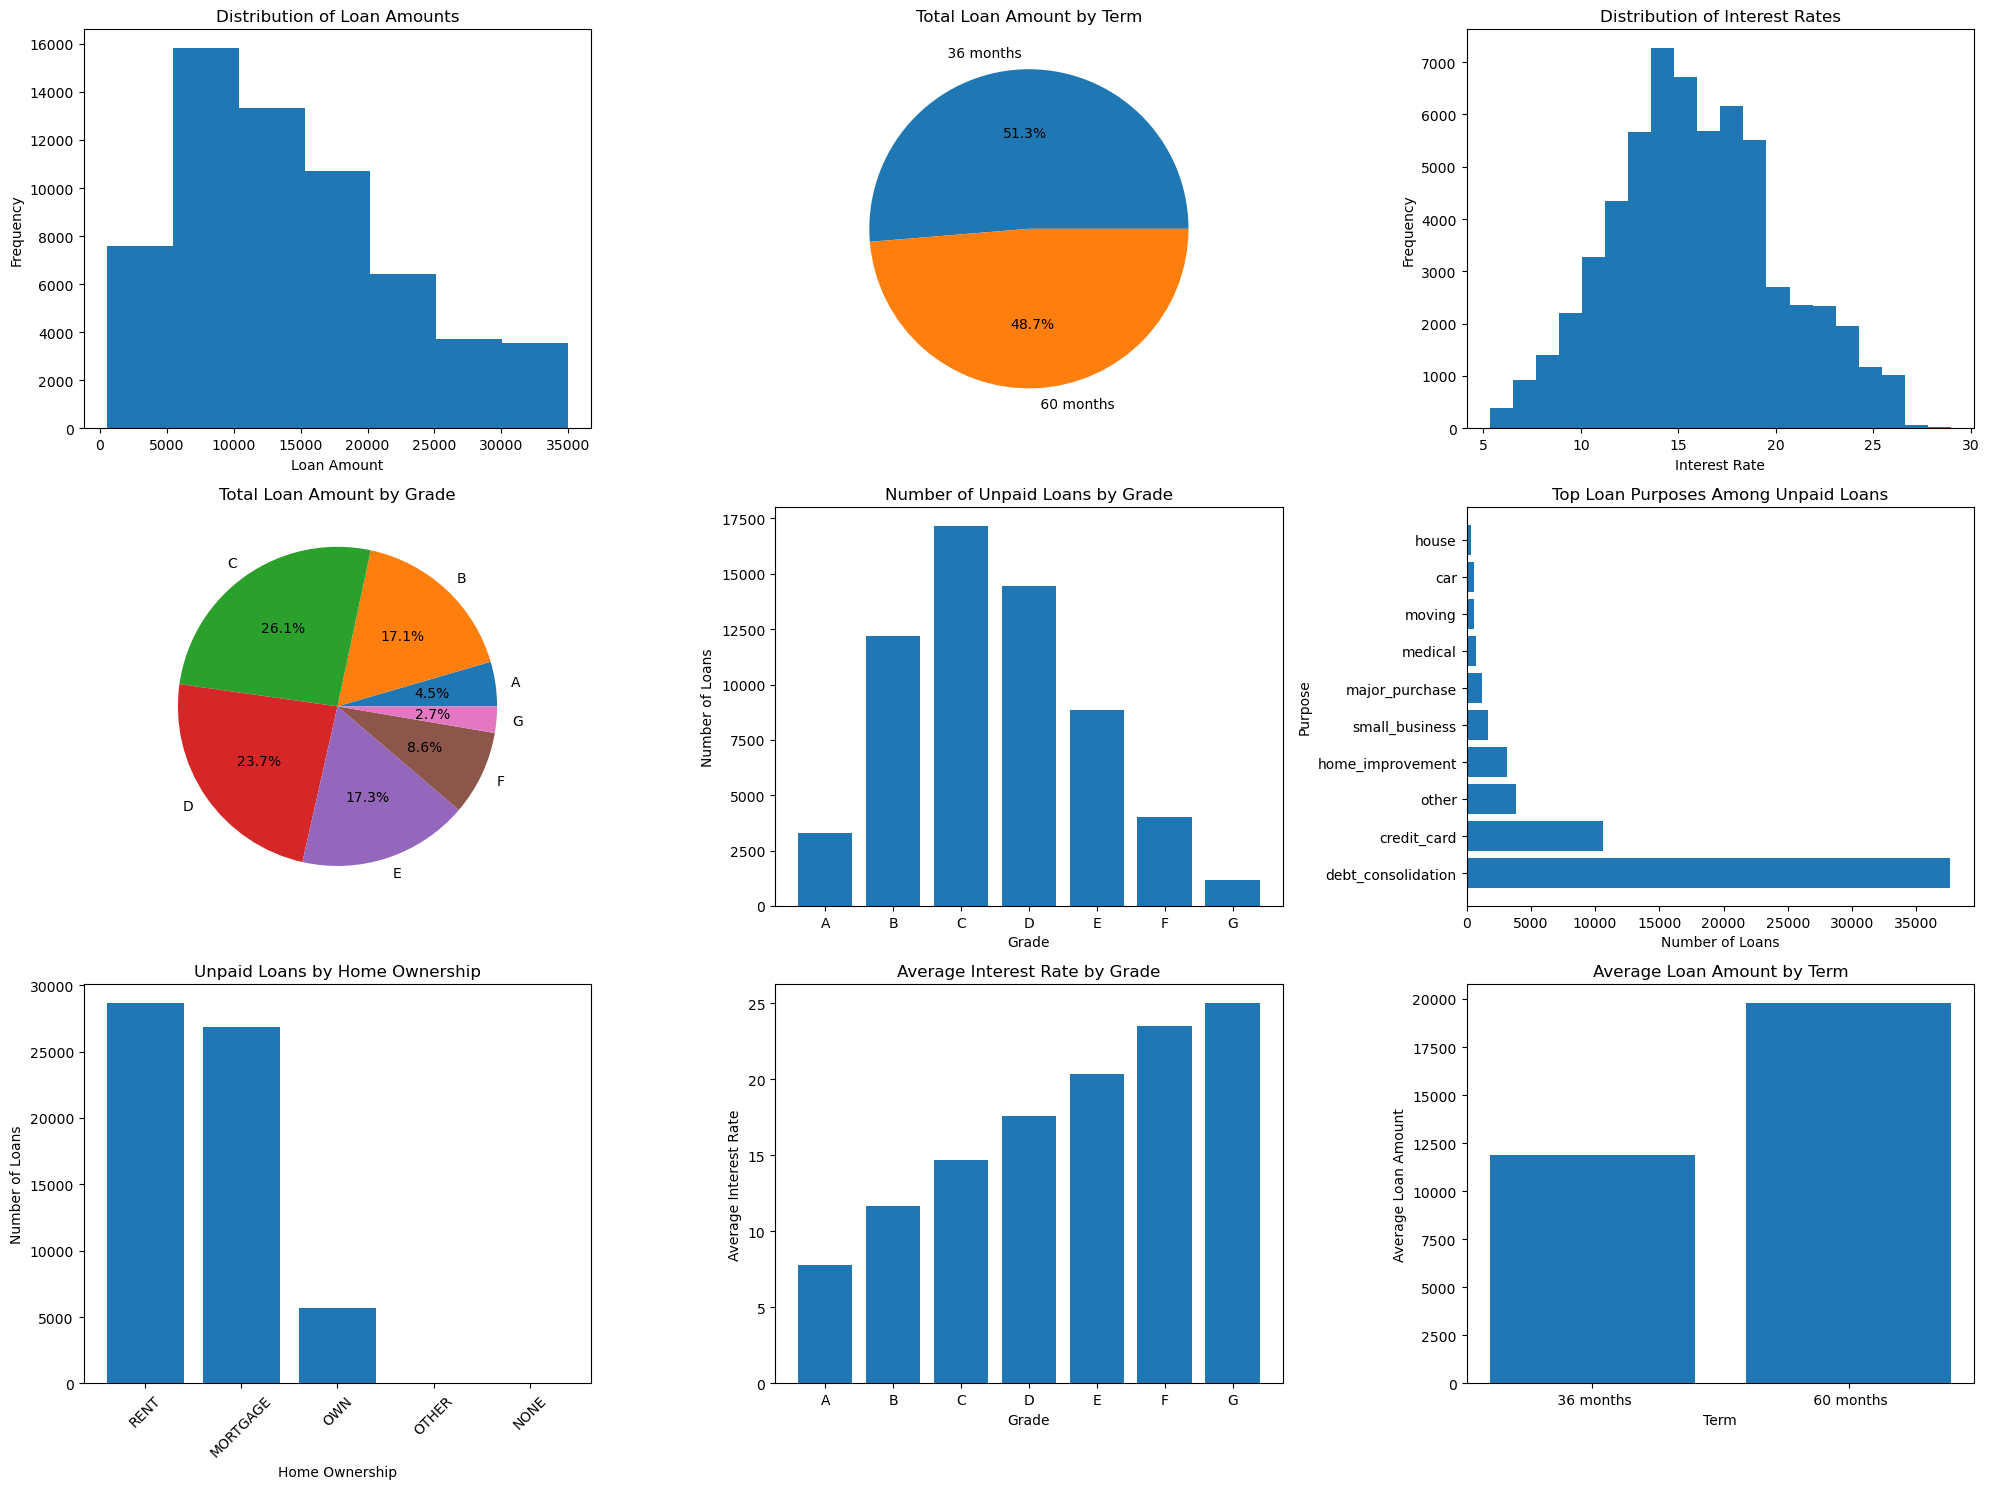

In [166]:
fig, ax = plt.subplots(3, 3, figsize=(20, 15))

# 1. Distribution of loan amounts among unpaid loans
ax[0, 0].hist(df_unpaid_loans['loan_amnt'], bins=7)
ax[0, 0].set_title('Distribution of Loan Amounts')
ax[0, 0].set_xlabel('Loan Amount')
ax[0, 0].set_ylabel('Frequency')


# 2. Total unpaid loan amount by loan term
loan_by_term = df_unpaid_loans.groupby('term')['loan_amnt'].sum()

ax[0, 1].pie(
    loan_by_term,
    labels=loan_by_term.index,
    autopct='%1.1f%%'
)
ax[0, 1].set_title('Total Loan Amount by Term')


# 3. Distribution of interest rates among unpaid loans
ax[0, 2].hist(df_unpaid_loans['int_rate'], bins=20)
ax[0, 2].set_title('Distribution of Interest Rates')
ax[0, 2].set_xlabel('Interest Rate')
ax[0, 2].set_ylabel('Frequency')


# 4. Total unpaid loan amount by grade
loan_by_grade = df_unpaid_loans.groupby('grade')['loan_amnt'].sum()

ax[1, 0].pie(
    loan_by_grade,
    labels=loan_by_grade.index,
    autopct='%1.1f%%'
)
ax[1, 0].set_title('Total Loan Amount by Grade')


# 5. Number of unpaid loans by grade
grade_counts = df_unpaid_loans['grade'].value_counts().sort_index()

ax[1, 1].bar(
    grade_counts.index,
    grade_counts.values
)
ax[1, 1].set_title('Number of Unpaid Loans by Grade')
ax[1, 1].set_xlabel('Grade')
ax[1, 1].set_ylabel('Number of Loans')


# 6. Number of unpaid loans by purpose
purpose_counts = df_unpaid_loans['purpose'].value_counts().head(10)

ax[1, 2].barh(
    purpose_counts.index,
    purpose_counts.values
)
ax[1, 2].set_title('Top Loan Purposes Among Unpaid Loans')
ax[1, 2].set_xlabel('Number of Loans')
ax[1, 2].set_ylabel('Purpose')


# 7. Number of unpaid loans by home ownership status
home_counts = df_unpaid_loans['home_ownership'].value_counts()

ax[2, 0].bar(
    home_counts.index,
    home_counts.values
)

ax[2, 0].set_title('Unpaid Loans by Home Ownership')
ax[2, 0].set_xlabel('Home Ownership')
ax[2, 0].set_ylabel('Number of Loans')
ax[2, 0].tick_params(axis='x', rotation=45)


# 8. Average interest rate by grade
avg_int_by_grade = df_unpaid_loans.groupby('grade')['int_rate'].mean().sort_index()

ax[2, 1].bar(
    avg_int_by_grade.index,
    avg_int_by_grade.values
)
ax[2, 1].set_title('Average Interest Rate by Grade')
ax[2, 1].set_xlabel('Grade')
ax[2, 1].set_ylabel('Average Interest Rate')


# 9. Average loan amount by term
avg_loan_by_term = df_unpaid_loans.groupby('term')['loan_amnt'].mean()

ax[2, 2].bar(
    avg_loan_by_term.index,
    avg_loan_by_term.values
)
ax[2, 2].set_title('Average Loan Amount by Term')
ax[2, 2].set_xlabel('Term')
ax[2, 2].set_ylabel('Average Loan Amount')


plt.tight_layout()
plt.show()

### Loan Characteristics Analysis

- The plots summarize important loan-level patterns among unpaid loans. The loan amount distribution shows that most unpaid loans are concentrated between lower and mid-range loan amounts, especially around the \$5,000 to \$20,000 range. There are fewer unpaid loans at very high loan amounts, although some loans still reach close to \$35,000.

- The term distribution shows that the total unpaid loan amount is almost evenly split between **36-month** and **60-month** loans. However, 36-month loans account for a slightly larger share of the total unpaid loan amount. This suggests that unpaid loans are not limited to longer-term loans; both short-term and long-term loans contribute significantly.

- The interest rate distribution is centered mostly around the mid-range interest rates, especially between about 12% and 20%. This indicates that many unpaid borrowers had moderate to relatively high interest rates. Very low and very high interest rates appear less frequently.

- The grade analysis shows that grades **C** and **D** contribute the largest share of unpaid loan amounts, followed by grades **E** and **B**. This suggests that mid-risk loan grades are heavily represented among unpaid loans. The bar chart also shows that grade **C** has the highest number of unpaid loans, followed by grade **D** and grade **B**.

- The loan purpose chart shows that **debt consolidation** is by far the most common purpose among unpaid loans. Credit card loans are the second most common, but they are much lower than debt consolidation. This suggests that many unpaid borrowers may have taken loans to manage or combine existing debt.

- The home ownership chart shows that most unpaid borrowers are either **renters** or borrowers with a **mortgage**. Borrowers who own homes outright appear much less often. This may indicate that borrowers with ongoing housing payments are more represented in the unpaid loan group.

- The average interest rate by grade increases steadily from grade **A** to grade **G**. This is expected because lower-grade loans are usually considered riskier, so they are assigned higher interest rates. Grade G has the highest average interest rate, while grade A has the lowest.

- Finally, the average loan amount by term shows that **60-month loans** have a much higher average loan amount than **36-month loans**. This makes sense because borrowers taking larger loans may prefer longer repayment periods to reduce monthly payments. Overall, the plots suggest that unpaid loans are strongly connected with loan grade, interest rate, loan purpose, and loan term.

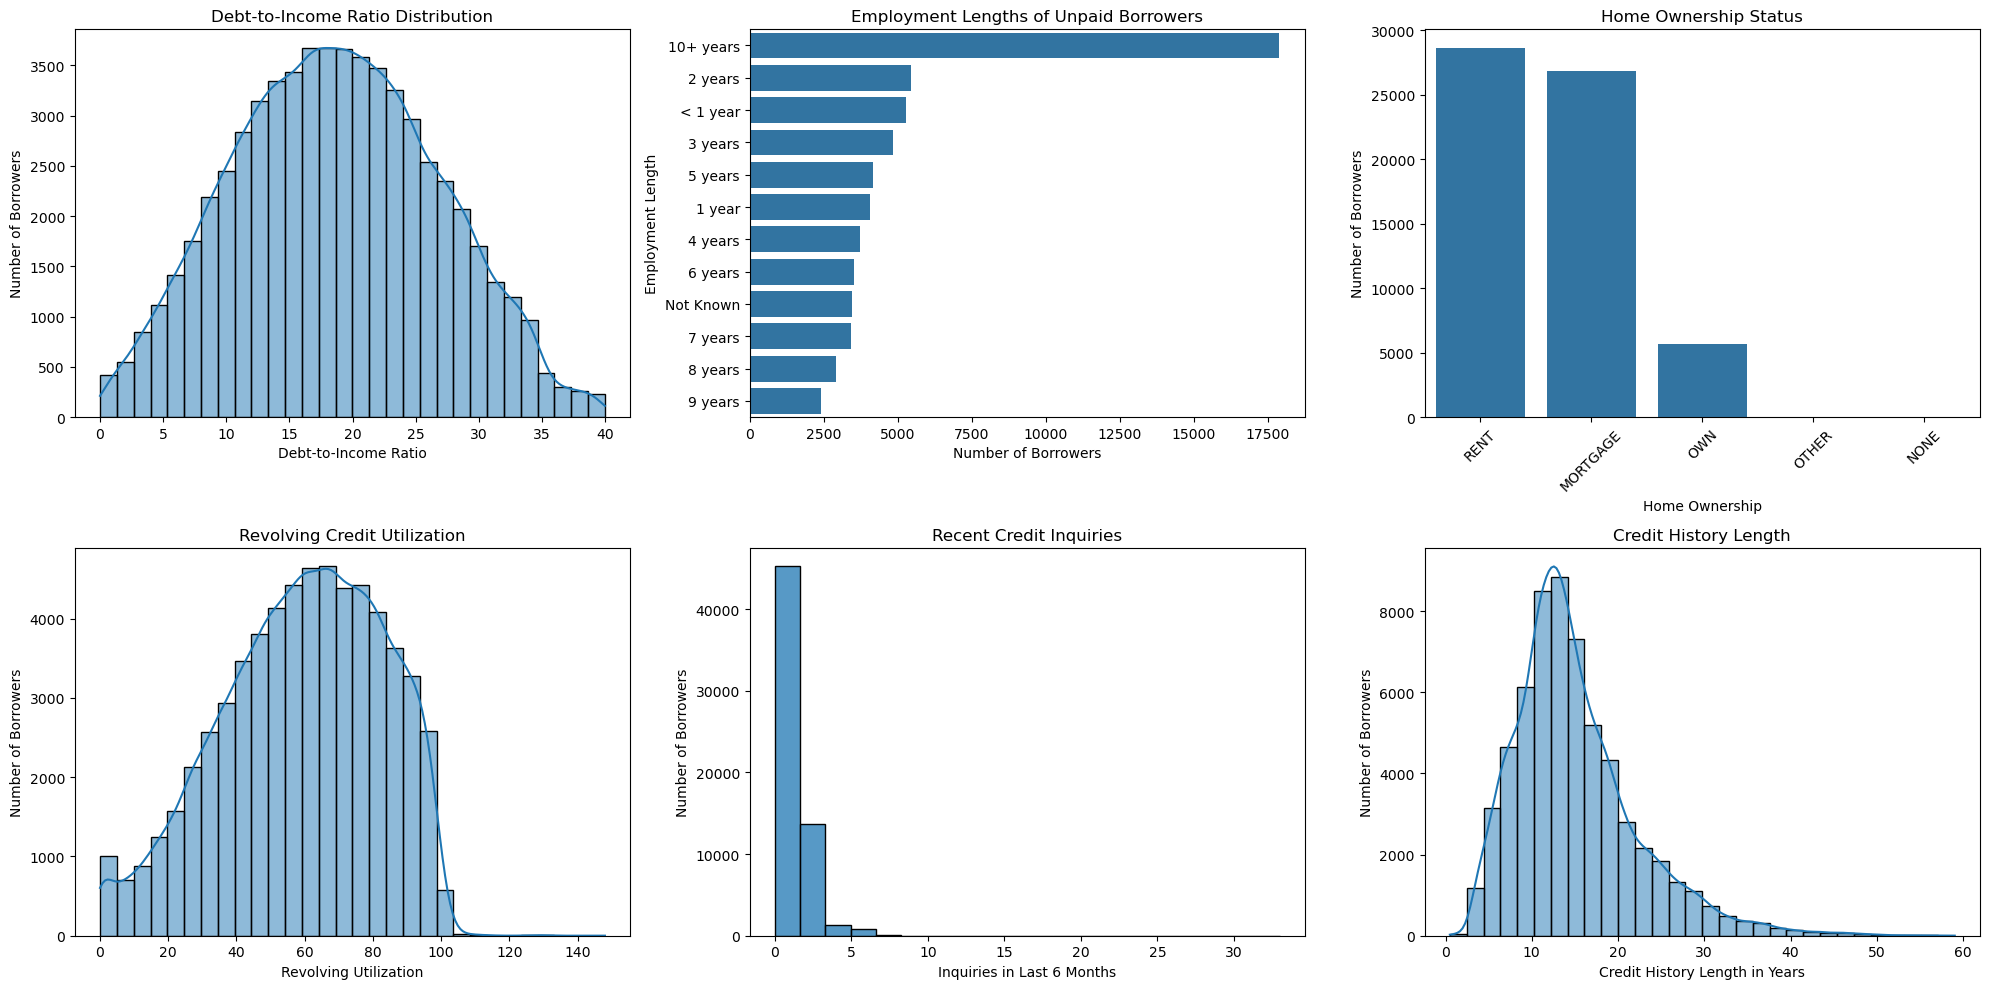

In [167]:
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# -----------------------------
# Borrower Characteristics
# -----------------------------

# 1. Debt-to-income ratio distribution
sns.histplot(
    data=df_unpaid_loans,
    x='dti',
    bins=30,
    kde=True,
    ax=ax[0, 0]
)

ax[0, 0].set_title('Debt-to-Income Ratio Distribution')
ax[0, 0].set_xlabel('Debt-to-Income Ratio')
ax[0, 0].set_ylabel('Number of Borrowers')


# 2. Most common employment lengths among unpaid borrowers
emp_counts = df_unpaid_loans['emp_length'].value_counts()

sns.barplot(
    x=emp_counts.values,
    y=emp_counts.index,
    ax=ax[0, 1]
)

ax[0, 1].set_title('Employment Lengths of Unpaid Borrowers')
ax[0, 1].set_xlabel('Number of Borrowers')
ax[0, 1].set_ylabel('Employment Length')


# 3. Home ownership status among unpaid borrowers
home_counts = df_unpaid_loans['home_ownership'].value_counts()

sns.barplot(
    x=home_counts.index,
    y=home_counts.values,
    ax=ax[0, 2]
)

ax[0, 2].set_title('Home Ownership Status')
ax[0, 2].set_xlabel('Home Ownership')
ax[0, 2].set_ylabel('Number of Borrowers')
ax[0, 2].tick_params(axis='x', rotation=45)


# -----------------------------
# Credit History
# -----------------------------

# 4. Revolving credit utilization distribution
sns.histplot(
    data=df_unpaid_loans,
    x='revol_util',
    bins=30,
    kde=True,
    ax=ax[1, 0]
)

ax[1, 0].set_title('Revolving Credit Utilization')
ax[1, 0].set_xlabel('Revolving Utilization')
ax[1, 0].set_ylabel('Number of Borrowers')


# 5. Recent credit inquiries
sns.histplot(
    data=df_unpaid_loans,
    x='inq_last_6mths',
    bins=20,
    ax=ax[1, 1]
)

ax[1, 1].set_title('Recent Credit Inquiries')
ax[1, 1].set_xlabel('Inquiries in Last 6 Months')
ax[1, 1].set_ylabel('Number of Borrowers')


# 6. Credit history length
df_unpaid_loans['earliest_cr_line'] = pd.to_datetime(
    df_unpaid_loans['earliest_cr_line'],
    errors='coerce'
)

df_unpaid_loans['issue_d'] = pd.to_datetime(
    df_unpaid_loans['issue_d'],
    errors='coerce'
)

df_unpaid_loans['credit_history_years'] = (
    df_unpaid_loans['issue_d'] - df_unpaid_loans['earliest_cr_line']
).dt.days / 365

sns.histplot(
    data=df_unpaid_loans,
    x='credit_history_years',
    bins=30,
    kde=True,
    ax=ax[1, 2]
)

ax[1, 2].set_title('Credit History Length')
ax[1, 2].set_xlabel('Credit History Length in Years')
ax[1, 2].set_ylabel('Number of Borrowers')


plt.tight_layout()
plt.show()

### Borrower Characteristics and Credit History Analysis

- The plots provide an overview of borrower characteristics and credit history patterns among unpaid loans. The analysis focuses on debt-to-income ratio, employment length, home ownership, revolving credit utilization, recent credit inquiries, and credit history length.

- The debt-to-income ratio distribution is approximately bell-shaped, with many unpaid borrowers concentrated in the middle range. This suggests that unpaid loans are not only associated with borrowers who have extremely high debt-to-income ratios. Many borrowers with moderate DTI values also appear in the unpaid loan group.

- Employment length shows that borrowers with **10+ years** of employment form the largest group among unpaid loans. This is interesting because longer employment history does not necessarily prevent loan default or non-payment. Other groups, such as borrowers with 2 years, less than 1 year, and 3 years of employment, also appear frequently.

- For home ownership, most unpaid borrowers are either **renters** or borrowers with a **mortgage**. Borrowers who own homes outright appear much less frequently. This may suggest that borrowers with rent or mortgage obligations are more represented among unpaid loans, possibly because they have larger monthly financial responsibilities.

- Revolving credit utilization is concentrated around moderate to high utilization levels, especially between about 40% and 90%. This suggests that many unpaid borrowers were using a significant portion of their available revolving credit, which may be an important signal of financial stress.

- Most unpaid borrowers have only a small number of recent credit inquiries, especially between 0 and 2 inquiries in the last six months. This means that frequent recent borrowing inquiries are not common for most unpaid borrowers, although a small number of borrowers have unusually high inquiry counts.

- Credit history length is mostly concentrated between about 10 and 20 years. This suggests that many unpaid borrowers are not new to credit; rather, they have established credit histories.

- Overall, these plots show that unpaid loans are associated with a mix of borrower profiles. Borrowers with unpaid loans often have moderate DTI values, long employment histories, rent or mortgage obligations, moderate-to-high revolving utilization, few recent inquiries, and established credit histories. No single factor alone explains non-payment.

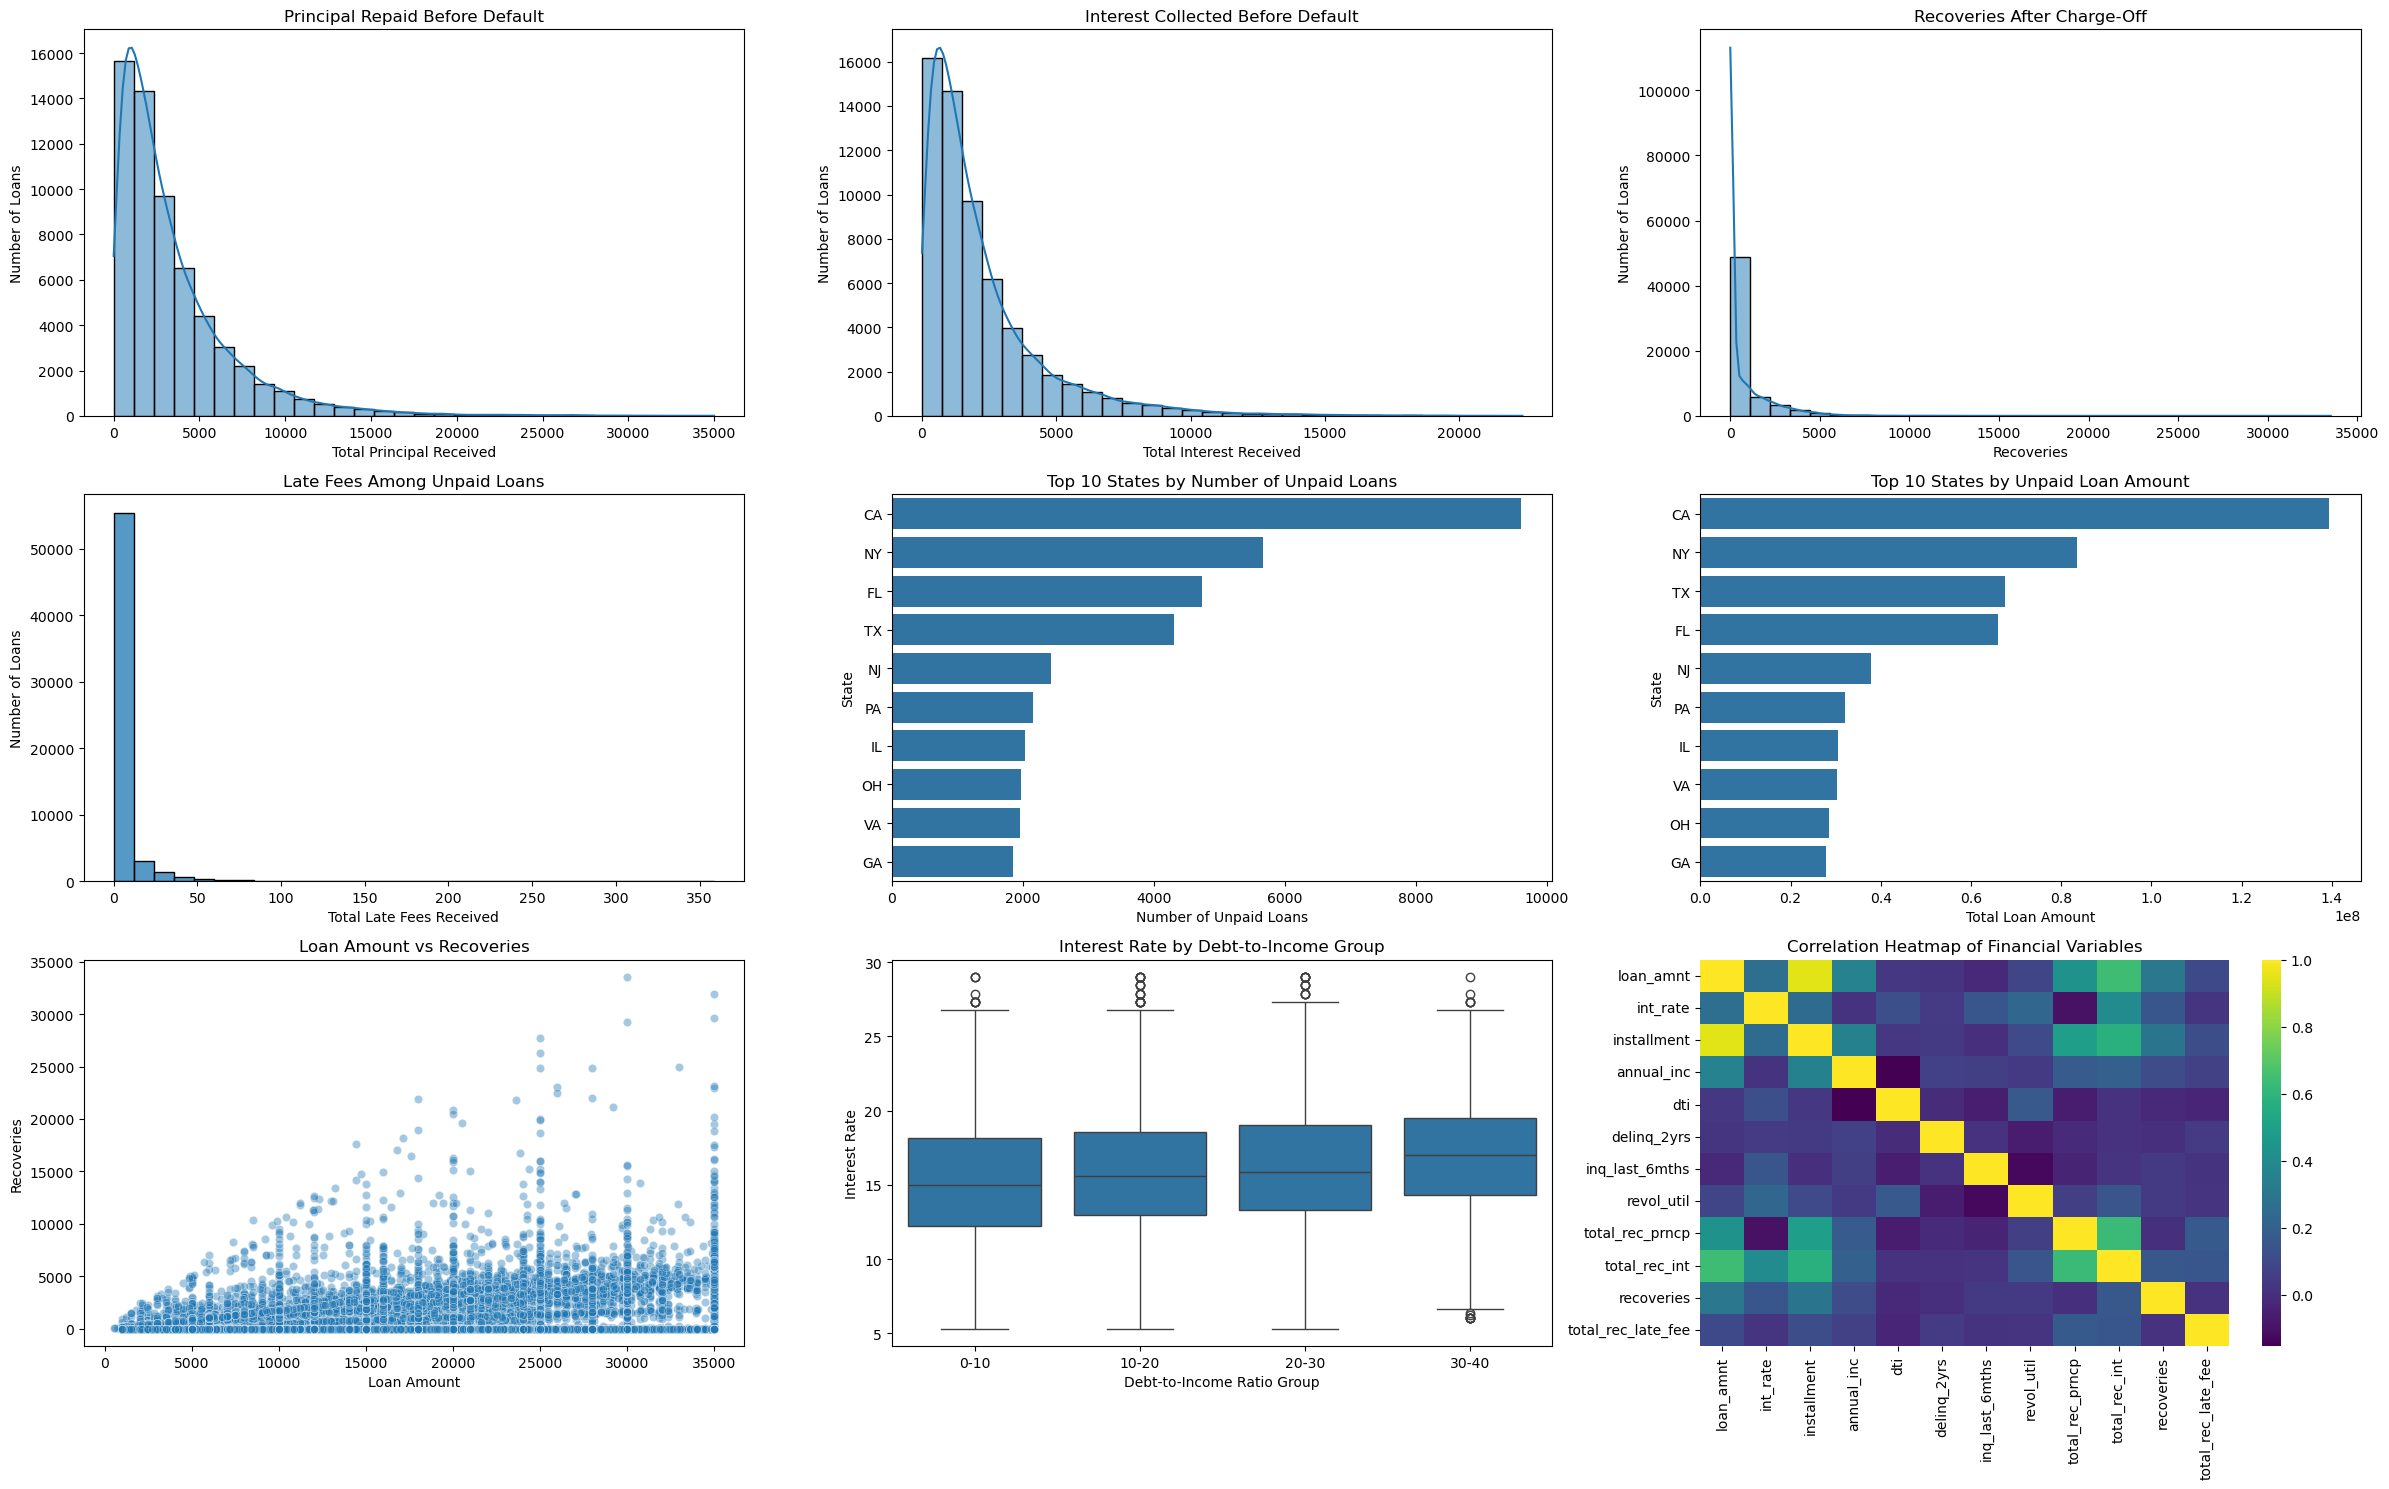

In [168]:
fig, ax = plt.subplots(3, 3, figsize=(24, 15))

# -----------------------------
# Payment History
# -----------------------------

# 1. How much principal was repaid before default?
sns.histplot(
    data=df_unpaid_loans,
    x='total_rec_prncp',
    bins=30,
    kde=True,
    ax=ax[0, 0]
)
ax[0, 0].set_title('Principal Repaid Before Default')
ax[0, 0].set_xlabel('Total Principal Received')
ax[0, 0].set_ylabel('Number of Loans')


# 2. How much interest was collected before the loan became unpaid?
sns.histplot(
    data=df_unpaid_loans,
    x='total_rec_int',
    bins=30,
    kde=True,
    ax=ax[0, 1]
)
ax[0, 1].set_title('Interest Collected Before Default')
ax[0, 1].set_xlabel('Total Interest Received')
ax[0, 1].set_ylabel('Number of Loans')


# 3. How much money was recovered after charge-offs?
sns.histplot(
    data=df_unpaid_loans,
    x='recoveries',
    bins=30,
    kde=True,
    ax=ax[0, 2]
)
ax[0, 2].set_title('Recoveries After Charge-Off')
ax[0, 2].set_xlabel('Recoveries')
ax[0, 2].set_ylabel('Number of Loans')


# -----------------------------
# Late Fees and Geographic Analysis
# -----------------------------

# 4. How common are late fees among unpaid loans?
sns.histplot(
    data=df_unpaid_loans,
    x='total_rec_late_fee',
    bins=30,
    ax=ax[1, 0]
)
ax[1, 0].set_title('Late Fees Among Unpaid Loans')
ax[1, 0].set_xlabel('Total Late Fees Received')
ax[1, 0].set_ylabel('Number of Loans')


# 5. Which states have the highest number of unpaid loans?
state_counts = df_unpaid_loans['addr_state'].value_counts().head(10)

sns.barplot(
    x=state_counts.values,
    y=state_counts.index,
    ax=ax[1, 1]
)
ax[1, 1].set_title('Top 10 States by Number of Unpaid Loans')
ax[1, 1].set_xlabel('Number of Unpaid Loans')
ax[1, 1].set_ylabel('State')


# 6. Which states have the highest unpaid loan amount?
state_loan_amount = (
    df_unpaid_loans
    .groupby('addr_state')['loan_amnt']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=state_loan_amount.values,
    y=state_loan_amount.index,
    ax=ax[1, 2]
)
ax[1, 2].set_title('Top 10 States by Unpaid Loan Amount')
ax[1, 2].set_xlabel('Total Loan Amount')
ax[1, 2].set_ylabel('State')


# -----------------------------
# Correlation Analysis
# -----------------------------

# 7. Is loan amount correlated with default severity?
# Here default severity is approximated using recoveries.
sns.scatterplot(
    data=df_unpaid_loans,
    x='loan_amnt',
    y='recoveries',
    alpha=0.4,
    ax=ax[2, 0]
)
ax[2, 0].set_title('Loan Amount vs Recoveries')
ax[2, 0].set_xlabel('Loan Amount')
ax[2, 0].set_ylabel('Recoveries')


# 8. Does higher DTI relate to higher interest rates?

# Create DTI groups
df_unpaid_loans['dti_group'] = pd.cut(
    df_unpaid_loans['dti'],
    bins=[0, 10, 20, 30, 40],
    labels=['0-10', '10-20', '20-30', '30-40']
)

sns.boxplot(
    data=df_unpaid_loans,
    x='dti_group',
    y='int_rate',
    ax=ax[2, 1]
)

ax[2, 1].set_title('Interest Rate by Debt-to-Income Group')
ax[2, 1].set_xlabel('Debt-to-Income Ratio Group')
ax[2, 1].set_ylabel('Interest Rate')


# 9. Which financial variables are most strongly correlated?
corr_cols = [
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'revol_util',
    'total_rec_prncp',
    'total_rec_int',
    'recoveries',
    'total_rec_late_fee'
]

corr_matrix = df_unpaid_loans[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='viridis',
    annot=False,
    ax=ax[2, 2]
)
ax[2, 2].set_title('Correlation Heatmap of Financial Variables')


plt.tight_layout()
plt.show()

### Payment History, Geographic, and Correlation Analysis

The plots summarize how unpaid loans behave in terms of repayment history, recoveries, late fees, geographic concentration, and relationships between financial variables.

The distribution of **principal repaid before default** is highly right-skewed. Most unpaid loans had only a relatively small amount of principal repaid before becoming unpaid, while a smaller number of loans had much larger principal payments before default. This suggests that many borrowers became delinquent or defaulted before paying back a large portion of the loan balance.

The **interest collected before default** follows a similar right-skewed pattern. Most loans generated a relatively small amount of interest before becoming unpaid, while a smaller group produced much higher interest payments. This may indicate that some borrowers continued making payments for a longer period before defaulting.

The **recoveries after charge-off** plot shows that recoveries are usually very low. Most unpaid loans have little or no recovered amount after charge-off, with only a small number of loans showing larger recoveries. This suggests that once a loan is charged off, the amount recovered is often limited.

The **late fee distribution** also shows that most unpaid loans have little or no late fees recorded. A small number of loans have higher late fees, but they are not common. This indicates that late fees are concentrated among a relatively small portion of unpaid borrowers.

The geographic plots show that unpaid loans are not evenly distributed across states. **California (CA)** has the highest number of unpaid loans and also the highest total unpaid loan amount. Other major states such as **New York (NY), Florida (FL), and Texas (TX)** also appear among the top states. This may partly reflect larger population size and higher lending activity in these states.

The scatter plot of **loan amount vs recoveries** shows that larger loans can have higher recoveries, but the relationship is not very strong. Many loans, even large ones, still have low recoveries. This suggests that loan size alone does not fully explain how much money is recovered after default.

The boxplot of **interest rate by debt-to-income group** shows that borrowers with higher DTI ratios tend to have slightly higher interest rates. The median interest rate increases gradually from the lower DTI group to the higher DTI group. This suggests that higher debt burden may be associated with higher borrowing cost.

The correlation heatmap shows relationships among financial variables. As expected, **loan amount** and **installment** are strongly positively correlated, because larger loans usually require larger monthly payments. **Total recovered principal** and **total recovered interest** also show positive relationships with loan and payment-related variables. Overall, the heatmap helps identify which financial variables move together and which variables have weaker relationships.

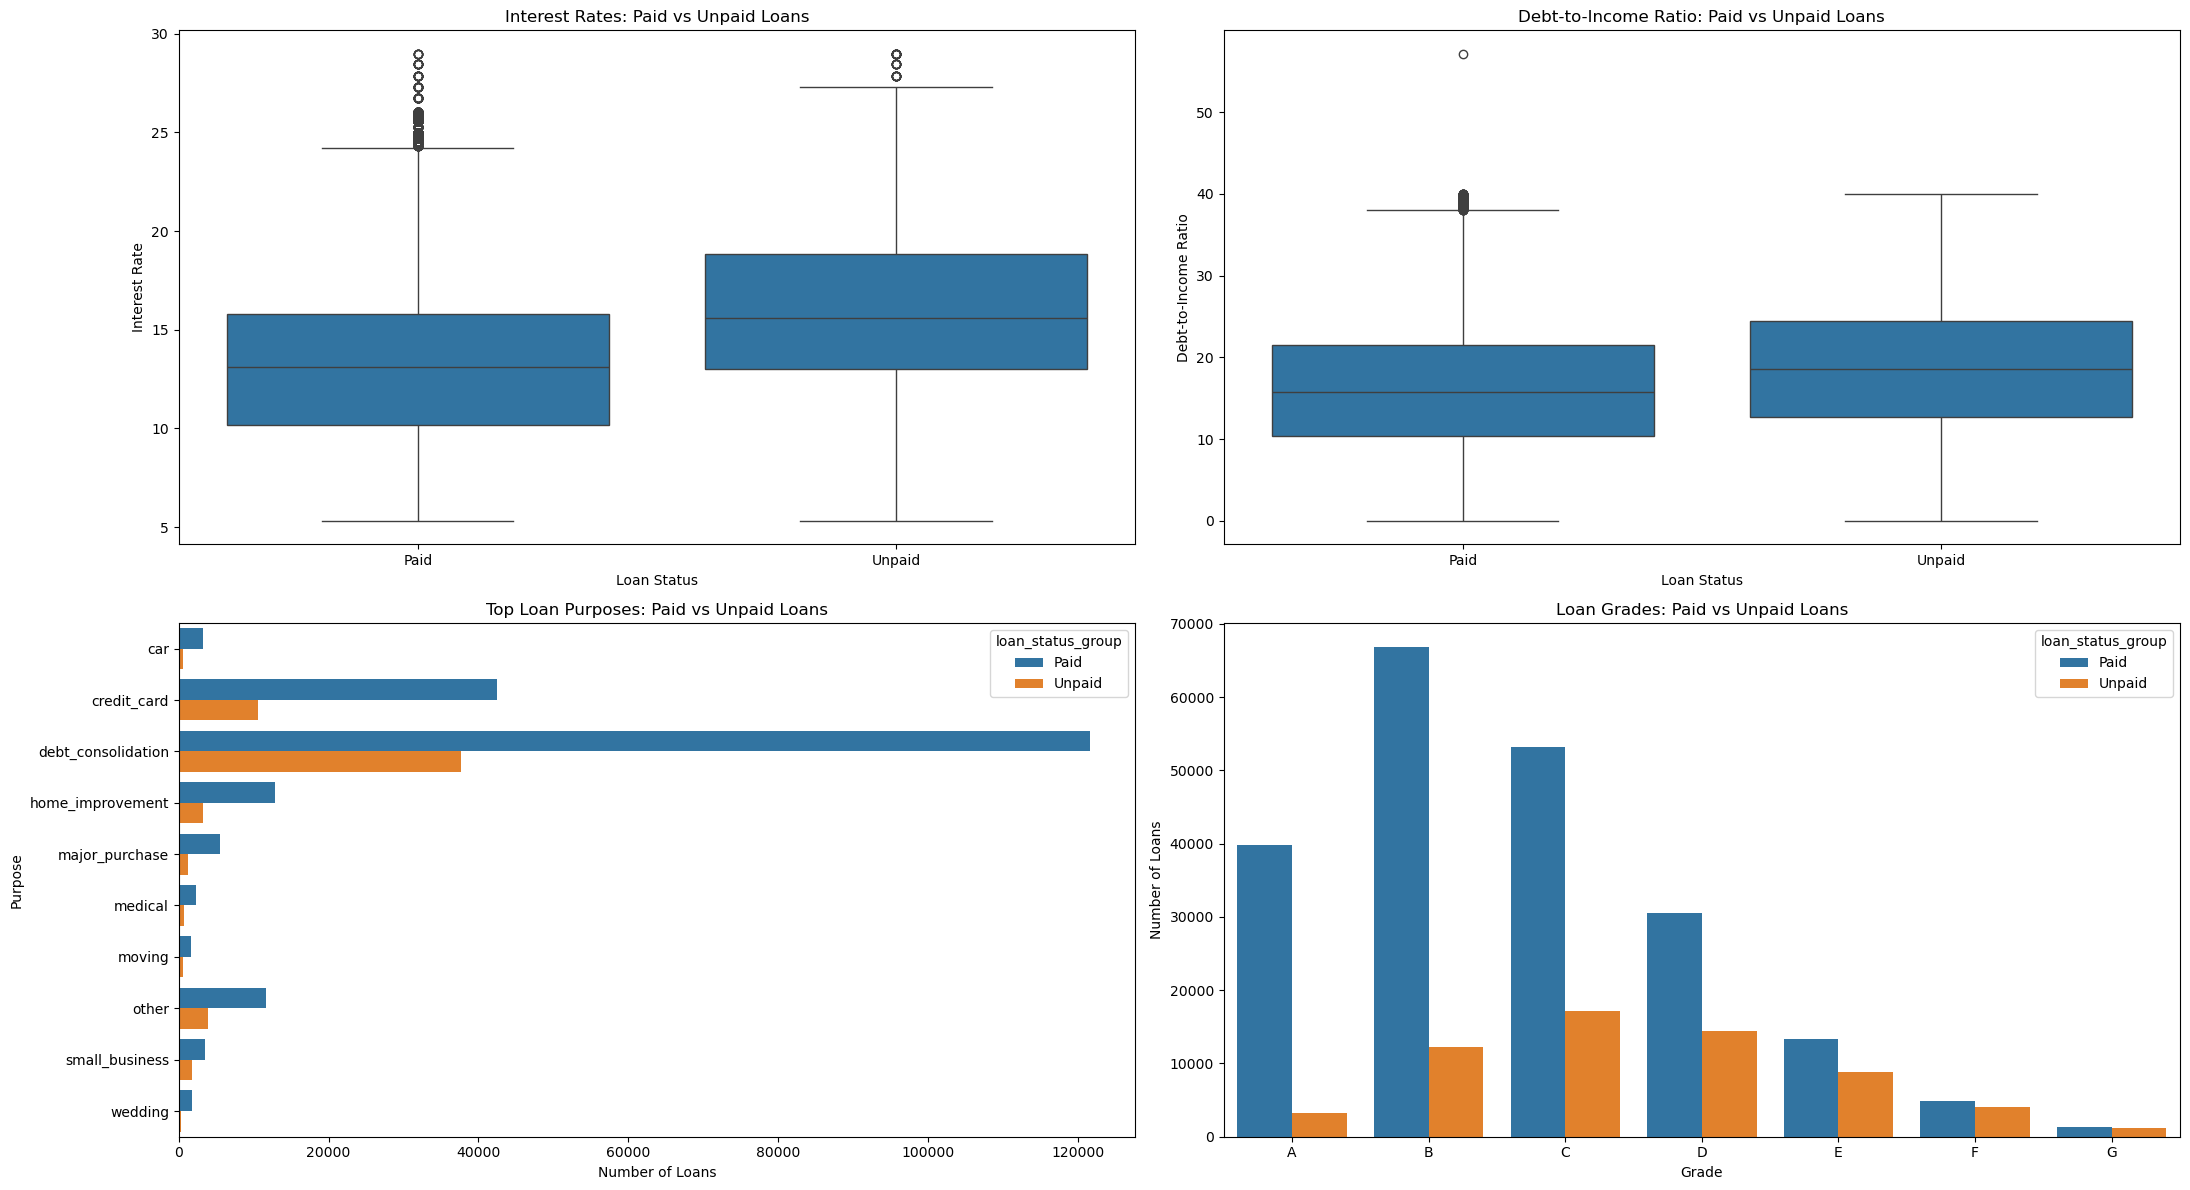

In [169]:
df_paid_loans = df_cl.iloc[loan_type_indices['paid_indices']].copy()

# Create copies
paid = df_paid_loans.copy()
unpaid = df_unpaid_loans.copy()

# Add loan status labels
paid['loan_status_group'] = 'Paid'
unpaid['loan_status_group'] = 'Unpaid'

# Combine both datasets
df_compare = pd.concat([paid, unpaid], axis=0)

# Create subplots
fig, ax = plt.subplots(2, 2, figsize=(22, 12))

# 1. Interest rates: paid vs unpaid
sns.boxplot(
    data=df_compare,
    x='loan_status_group',
    y='int_rate',
    ax=ax[0, 0]
)
ax[0, 0].set_title('Interest Rates: Paid vs Unpaid Loans')
ax[0, 0].set_xlabel('Loan Status')
ax[0, 0].set_ylabel('Interest Rate')


# 2. Debt-to-income ratio: paid vs unpaid
sns.boxplot(
    data=df_compare,
    x='loan_status_group',
    y='dti',
    ax=ax[0, 1]
)
ax[0, 1].set_title('Debt-to-Income Ratio: Paid vs Unpaid Loans')
ax[0, 1].set_xlabel('Loan Status')
ax[0, 1].set_ylabel('Debt-to-Income Ratio')


# 3. Loan purposes: paid vs unpaid
purpose_counts = (
    df_compare
    .groupby(['loan_status_group', 'purpose'])
    .size()
    .reset_index(name='count')
)

# Keep top 10 purposes overall
top_purposes = df_compare['purpose'].value_counts().head(10).index
purpose_counts = purpose_counts[purpose_counts['purpose'].isin(top_purposes)]

sns.barplot(
    data=purpose_counts,
    x='count',
    y='purpose',
    hue='loan_status_group',
    ax=ax[1, 0]
)
ax[1, 0].set_title('Top Loan Purposes: Paid vs Unpaid Loans')
ax[1, 0].set_xlabel('Number of Loans')
ax[1, 0].set_ylabel('Purpose')


# 4. Credit grades: paid vs unpaid
grade_counts = (
    df_compare
    .groupby(['loan_status_group', 'grade'])
    .size()
    .reset_index(name='count')
)

sns.barplot(
    data=grade_counts,
    x='grade',
    y='count',
    hue='loan_status_group',
    ax=ax[1, 1]
)
ax[1, 1].set_title('Loan Grades: Paid vs Unpaid Loans')
ax[1, 1].set_xlabel('Grade')
ax[1, 1].set_ylabel('Number of Loans')

plt.tight_layout()
plt.show()

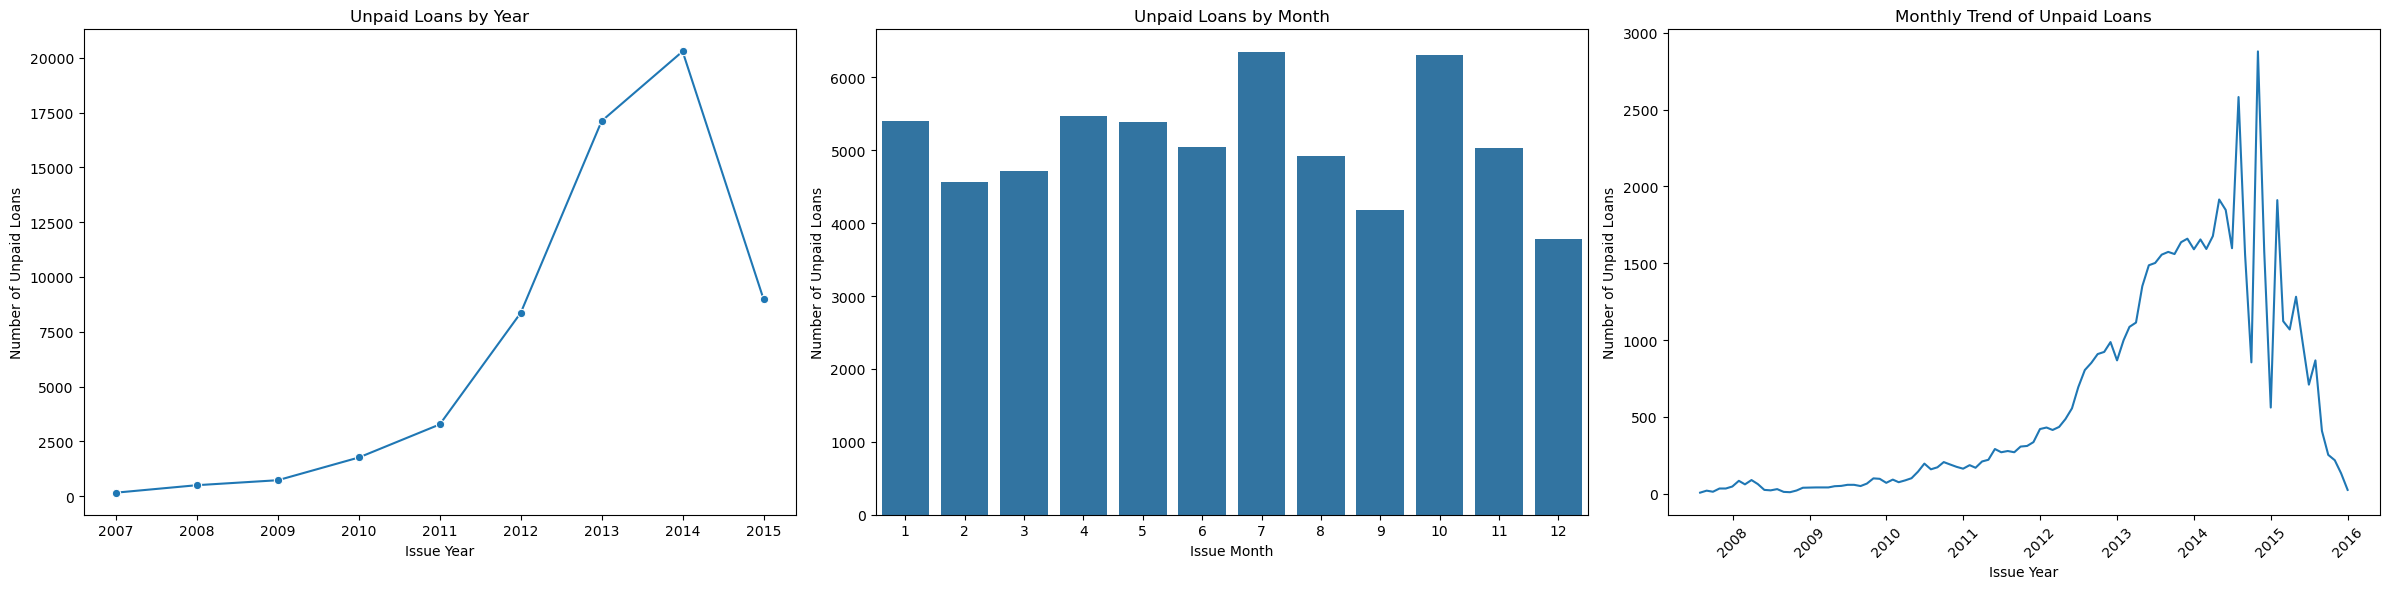

In [170]:
# Convert issue date to datetime
df_unpaid_loans['issue_d'] = pd.to_datetime(df_unpaid_loans['issue_d'], errors='coerce')

# Create year, month, and year-month columns
df_unpaid_loans['issue_year'] = df_unpaid_loans['issue_d'].dt.year
df_unpaid_loans['issue_month'] = df_unpaid_loans['issue_d'].dt.month
df_unpaid_loans['issue_year_month'] = df_unpaid_loans['issue_d'].dt.to_period('M').astype(str)

fig, ax = plt.subplots(1, 3, figsize=(24, 6))

# 1. Did unpaid loans increase during certain years?
year_counts = df_unpaid_loans['issue_year'].value_counts().sort_index()

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o',
    ax=ax[0]
)

ax[0].set_title('Unpaid Loans by Year')
ax[0].set_xlabel('Issue Year')
ax[0].set_ylabel('Number of Unpaid Loans')


# 2. Are there seasonal trends in loan defaults?
month_counts = df_unpaid_loans['issue_month'].value_counts().sort_index()

sns.barplot(
    x=month_counts.index,
    y=month_counts.values,
    ax=ax[1]
)

ax[1].set_title('Unpaid Loans by Month')
ax[1].set_xlabel('Issue Month')
ax[1].set_ylabel('Number of Unpaid Loans')


# 3. Did unpaid loans change over time?
df_unpaid_loans['issue_d'] = pd.to_datetime(df_unpaid_loans['issue_d'], errors='coerce')

monthly_counts = (
    df_unpaid_loans
    .groupby(pd.Grouper(key='issue_d', freq='M'))
    .size()
    .reset_index(name='count')
)

sns.lineplot(data=monthly_counts, x='issue_d', y='count', ax=ax[2])

ax[2].set_title('Monthly Trend of Unpaid Loans')
ax[2].set_xlabel('Issue Year')
ax[2].set_ylabel('Number of Unpaid Loans')
ax[2].xaxis.set_major_locator(mdates.YearLocator())
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Time Analysis of Unpaid Loans

- The time-based plots show how unpaid loans changed across years, months, and monthly issue dates. The yearly trend shows a clear increase in unpaid loans from 2007 to 2014. The number of unpaid loans was very low in the earlier years, then gradually increased from 2010 to 2012, followed by a sharp rise in 2013 and 2014. The highest number of unpaid loans appears in 2014. After 2014, there is a noticeable drop in 2015.

- The monthly bar chart shows that unpaid loans are distributed across all months, but some months have higher counts than others. July and October have the highest number of unpaid loans, while December has the lowest. This suggests that there may be some seasonal variation, although the differences are not extreme enough to conclude that month alone explains unpaid loan behavior.

- The monthly trend plot gives a more detailed view over time. It shows that unpaid loans increased steadily over several years, especially after 2011. There is a strong upward trend from 2012 through 2014, followed by several sharp fluctuations near the end of the dataset. The decline after 2014 may be related to incomplete data for later years or fewer loans reaching unpaid status by the time the dataset was collected.

- Overall, the time analysis suggests that unpaid loans became more common over time, especially between 2012 and 2014. However, the drop in 2015 should be interpreted carefully because it may reflect dataset coverage rather than an actual decrease in loan risk.